<a href="https://colab.research.google.com/github/sudeeraattanayake/Machine-Learning/blob/main/K_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

customer segmentation

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv('/content/customer_spending_dataset.csv')

In [30]:
X = df.iloc[:,:-1].values

In [29]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

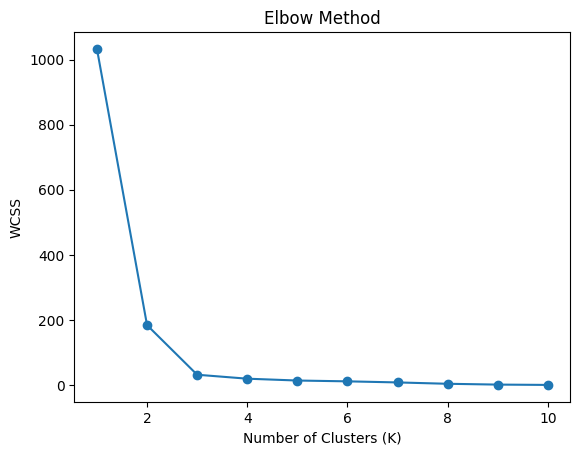

In [31]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [32]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = model.fit_predict(X)
print(df)

   CustomerID  Age  MonthlySpend  Cluster
0           1   22            15        2
1           2   25            20        2
2           3   24            18        2
3           4   45            80        0
4           5   50            85        0
5           6   48            78        0
6           7   30            40        1
7           8   32            42        1
8           9   29            38        1
9          10   31            45        1


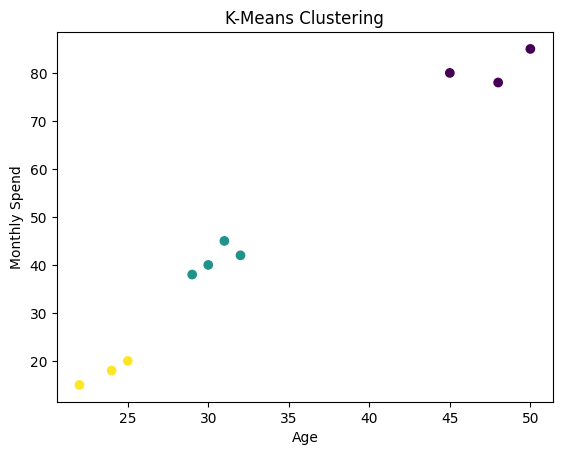

In [33]:
plt.scatter(df["Age"], df["MonthlySpend"],
c=df["Cluster"], cmap="viridis")
plt.xlabel("Age")
plt.ylabel("Monthly Spend")
plt.title("K-Means Clustering")
plt.show()

In [34]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, df["Cluster"])

print("Silhouette Score =", score)

Silhouette Score = 0.7504153974274043
